# Electrical Time Series Data Classification with TimeCNN

## Prepare Notebook

In [9]:
import sys
from pathlib import Path

p = Path.cwd().resolve()
while p.name != "tinyml-timeseries" and p.parent != p:
    p = p.parent

REPO_ROOT = p
sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("sys.path[0]:", sys.path[0])

REPO_ROOT: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries
sys.path[0]: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries


## Data Preparation

### Data Loading

In [10]:
import src.data.io as data_io
from src.data.split import stratified_split
from src.data.preprocessing import (
    clean_train_test,
    minmax_fit_transform_per_feature,
    one_hot_encode_labels,
)

# load
ed_data, ed_labels = data_io.load_data_sliding()

X_train, X_test, y_train, y_test = stratified_split(ed_data, ed_labels)
X_train, X_test = clean_train_test(X_train, X_test)
X_train, X_test, scalers = minmax_fit_transform_per_feature(X_train, X_test)

X_train_final, X_val, y_train_final, y_val = stratified_split(X_train, y_train)
y_train_final, y_val, y_test, num_classes = one_hot_encode_labels(
    y_train_final, y_val, y_test
)

print("\nFinal shapes:")
print("Train", X_train_final.shape)
print("Val", X_val.shape)
print("Test", X_test.shape)
print("Classes:", num_classes)

Stratified split successful
NaN & Inf values cleaned.
Data normalization complete (MinMax per feature).
Stratified split successful
One-hot encoding complete. Classes: 9

Final shapes:
Train (27105, 30, 5)
Val (6777, 30, 5)
Test (8471, 30, 5)
Classes: 9


### Dataset Size

In [11]:
import numpy as np

train_size_bytes = X_train_final.nbytes
print(f"Train Set Size in MB: {train_size_bytes / (1024 * 1024):.2f} MB")

Train Set Size in MB: 31.02 MB


## TimeCNN Model

### Building

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, ReLU, GlobalAveragePooling1D, Dense

timesteps = 30
n_features = 5
n_classes = 9

def create_timecnn():
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, padding="same", activation=None, input_shape=(timesteps, n_features)),
        BatchNormalization(),
        ReLU(),

        Conv1D(filters=128, kernel_size=5, padding="same", activation=None),
        BatchNormalization(),
        ReLU(),

        Conv1D(filters=256, kernel_size=7, padding="same", activation=None),
        BatchNormalization(),
        ReLU(),

        GlobalAveragePooling1D(),

        Dense(n_classes, activation="softmax")  # TimeCNN’de genellikle tek bir çıkış katmanı olur
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

time_cnn_model = create_timecnn()
time_cnn_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 30, 64)            1024      
                                                                 
 batch_normalization_3 (Bat  (None, 30, 64)            256       
 chNormalization)                                                
                                                                 
 re_lu_3 (ReLU)              (None, 30, 64)            0         
                                                                 
 conv1d_4 (Conv1D)           (None, 30, 128)           41088     
                                                                 
 batch_normalization_4 (Bat  (None, 30, 128)           512       
 chNormalization)                                                
                                                                 
 re_lu_4 (ReLU)              (None, 30, 128)          

### Training

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def train_timecnn(model, X_train, y_train, X_val, y_val,
              epochs=50, batch_size=64, save_best_model=True):
    callbacks = []

    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    callbacks.append(early_stopping)

    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
    callbacks.append(lr_scheduler)

    if save_best_model:
        model_checkpoint = ModelCheckpoint("best_time_cnn_model.h5", save_best_only=True, monitor="val_loss")
        callbacks.append(model_checkpoint)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    return history

history = train_timecnn(time_cnn_model,
                    X_train_final, y_train_final,
                    X_val, y_val,
                    epochs=50,
                    batch_size=64,
                    save_best_model=True)

Epoch 1/50
424/424 [==============================] - 7s 15ms/step - loss: 0.4033 - accuracy: 0.8551 - val_loss: 0.7595 - val_accuracy: 0.7692 - lr: 0.0010
Epoch 2/50
 10/424 [..............................] - ETA: 7s - loss: 0.2675 - accuracy: 0.9125

/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


424/424 [==============================] - 7s 17ms/step - loss: 0.2936 - accuracy: 0.8918 - val_loss: 0.2534 - val_accuracy: 0.9081 - lr: 0.0010
Epoch 3/50
424/424 [==============================] - 7s 18ms/step - loss: 0.2402 - accuracy: 0.9121 - val_loss: 0.2215 - val_accuracy: 0.9041 - lr: 0.0010
Epoch 4/50
424/424 [==============================] - 8s 18ms/step - loss: 0.2214 - accuracy: 0.9192 - val_loss: 0.2282 - val_accuracy: 0.9095 - lr: 0.0010
Epoch 5/50
424/424 [==============================] - 7s 17ms/step - loss: 0.1975 - accuracy: 0.9251 - val_loss: 0.2097 - val_accuracy: 0.9274 - lr: 0.0010
Epoch 6/50
424/424 [==============================] - 7s 17ms/step - loss: 0.1815 - accuracy: 0.9320 - val_loss: 0.2090 - val_accuracy: 0.9115 - lr: 0.0010
Epoch 7/50
424/424 [==============================] - 7s 17ms/step - loss: 0.1759 - accuracy: 0.9329 - val_loss: 0.1509 - val_accuracy: 0.9498 - lr: 0.0010
Epoch 8/50
424/424 [==============================] - 7s 17ms/step - loss: 

## Evaluation

### Training Performance

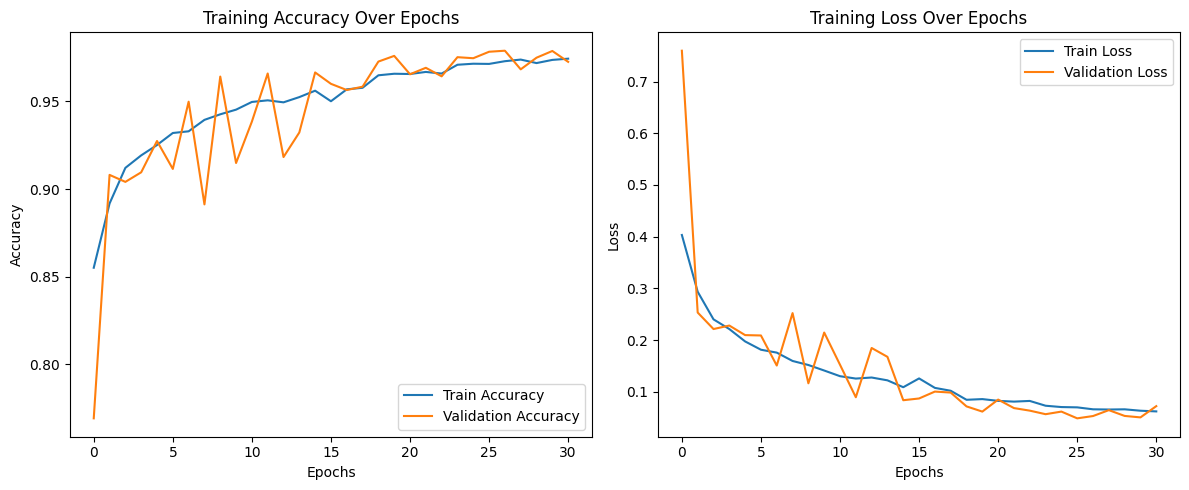

In [14]:
from src.utils.visualization import plot_training_history

plot_training_history(history)

### Classification Metrics

265/265 [==============================] - 1s 3ms/step

Test Accuracy: 0.9821

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     1.0000    0.9947    0.9973       188
           2     0.9876    0.9370    0.9616       508
           3     0.9269    0.9517    0.9392       373
           4     0.9938    0.9873    0.9906      2603
           5     0.9802    0.9969    0.9885      1938
           6     0.9534    1.0000    0.9761       511
           7     1.0000    0.6122    0.7595        98
           8     0.9203    0.9482    0.9340       463

    accuracy                         0.9821      8471
   macro avg     0.9736    0.9365    0.9496      8471
weighted avg     0.9824    0.9821    0.9816      8471



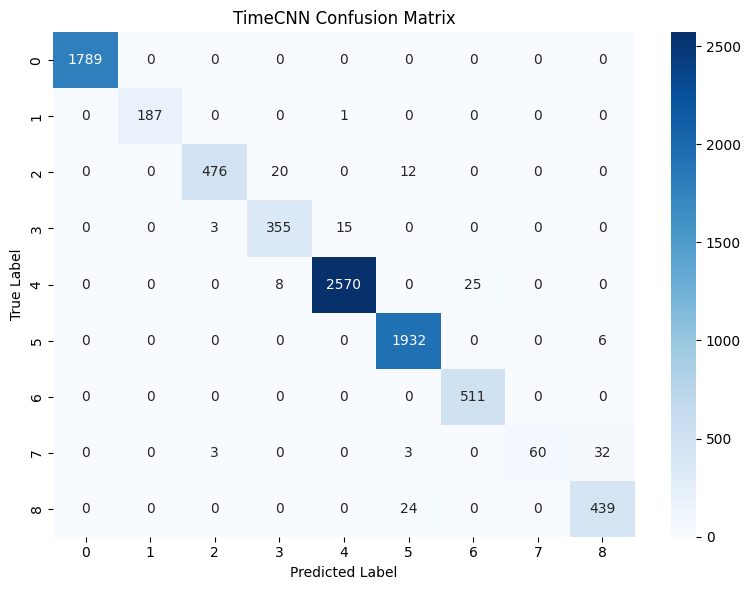

In [15]:
from src.evaluation.metrics import (
    evaluate_classification,
    plot_confusion_matrix
)

accuracy, report, y_pred = evaluate_classification(
    time_cnn_model,
    X_test,
    y_test
)

y_true = y_test.argmax(axis=1)

cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="TimeCNN Confusion Matrix"
)

### Model Saving and Size Check

In [16]:
import os

time_cnn_model.save("../../models/time_cnn_model.h5")

model_size = os.path.getsize("../../models/time_cnn_model.h5") / (1024 * 1024)
print(f"Real Model Size: {model_size:.2f} MB")

Real Model Size: 3.22 MB


/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## TinyML Performance

### TF Lite Conversion

In [17]:
from src.deployment.export import export_tflite_int8

TFLITE_MODEL_PATH = "../../models/time_cnn_model_quantized.tflite"

export_tflite_int8(
    model=time_cnn_model,
    X_calibration=X_train,
    save_path=TFLITE_MODEL_PATH,
    n_samples=200
)

INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmp6ag8tjon/assets


INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmp6ag8tjon/assets
/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-02-27 23:53:42.691137: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-02-27 23:53:42.691151: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-02-27 23:53:42.691300: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmp6ag8tjon
2026-02-27 23:53:42.692367: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-02-27 23:53:42.692371: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/fold

Quantized model saved: ../../models/time_cnn_model_quantized.tflite (287.85 KB)


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


b' \x00\x00\x00TFL3\x00\x00\x00\x00\x14\x00 \x00\x1c\x00\x18\x00\x14\x00\x10\x00\x0c\x00\x00\x00\x08\x00\x04\x00\x14\x00\x00\x00\x1c\x00\x00\x00\x88\x00\x00\x00\xe0\x00\x00\x00\xb86\x04\x00\xc86\x04\x00\xa4~\x04\x00\x03\x00\x00\x00\x01\x00\x00\x00\x04\x00\x00\x00\x0e\xc7\xfb\xff\x0c\x00\x00\x00\x1c\x00\x00\x008\x00\x00\x00\x0f\x00\x00\x00serving_default\x00\x01\x00\x00\x00\x04\x00\x00\x00\x94\xff\xff\xff\x19\x00\x00\x00\x04\x00\x00\x00\x07\x00\x00\x00dense_1\x00\x01\x00\x00\x00\x04\x00\x00\x00\xfe\xc8\xfb\xff\x04\x00\x00\x00\x0e\x00\x00\x00conv1d_3_input\x00\x00\x02\x00\x00\x004\x00\x00\x00\x04\x00\x00\x00\xdc\xff\xff\xff\x1c\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00CONVERSION_METADATA\x00\x08\x00\x0c\x00\x08\x00\x04\x00\x08\x00\x00\x00\x1b\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00min_runtime_version\x00\x1d\x00\x00\x00\xd45\x04\x00\xcc5\x04\x00\xb85\x04\x00\x9c5\x04\x00\x805\x04\x00d5\x04\x00P5\x04\x00\x1c5\x04\x00\x0c,\x04\x00\xfc\'\x04\x00\xec\xa7\x00\x00\xdc\xa5\x00\x00\xcc\x05

### Evaluation

In [18]:
from src.deployment.inference import (
    load_tflite_model, 
    run_tflite_inference
)

interpreter = load_tflite_model(TFLITE_MODEL_PATH)

y_pred = run_tflite_inference(interpreter, X_test)
y_true = np.argmax(y_test, axis=1)

print("TFLite model prediction completed.")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite model prediction completed.


### Test Classification Report

In [19]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

classification_rep = classification_report(y_true, y_pred, digits=4)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_rep)

Test Accuracy: 0.9832
Precision: 0.9835
Recall: 0.9832
F1-score: 0.9829

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     1.0000    0.9947    0.9973       188
           2     0.9799    0.9606    0.9702       508
           3     0.9269    0.9517    0.9392       373
           4     0.9946    0.9846    0.9896      2603
           5     0.9797    0.9974    0.9885      1938
           6     0.9534    1.0000    0.9761       511
           7     1.0000    0.6531    0.7901        98
           8     0.9461    0.9482    0.9471       463

    accuracy                         0.9832      8471
   macro avg     0.9756    0.9434    0.9553      8471
weighted avg     0.9835    0.9832    0.9829      8471



### Confusion Matrix

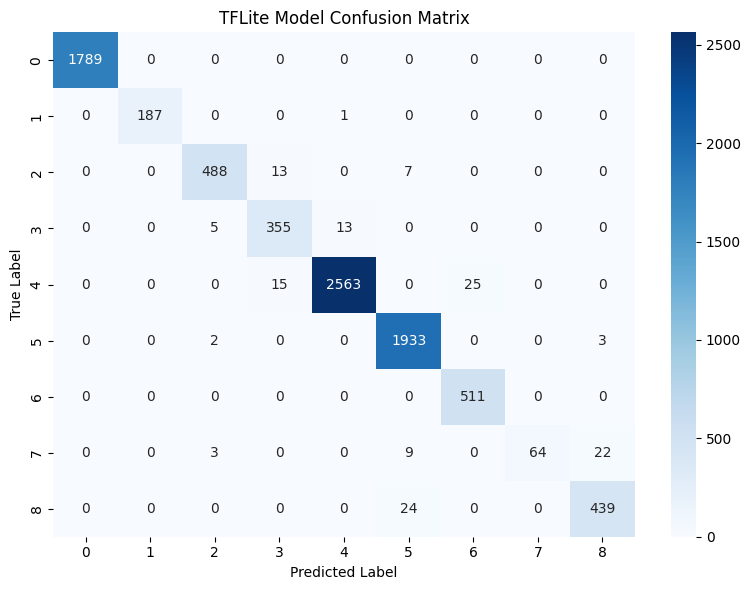

In [20]:
cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="TFLite Model Confusion Matrix"
)

### Model Size

In [21]:
import os

tflite_model_path = "../../models/time_cnn_model_quantized.tflite"

tflite_model_size = os.path.getsize(tflite_model_path)

print(f"TFLite Model Size: {tflite_model_size / 1024:.2f} KB")

TFLite Model Size: 287.85 KB


### ESP32 Compatible Header File Creation

In [22]:
from src.deployment.export import tflite_to_c_header

tflite_to_c_header(
    "../../models/time_cnn_model_quantized.tflite",
    var_name="time_cnn_model"
)

C header created: ../../models/time_cnn_model_quantized.h
Size: 287.85 KB


PosixPath('../../models/time_cnn_model_quantized.h')